# Training Analysis Notebook

This notebook analyzes the trained models on a classification task ordinary vs accidental.

## Contents

- Loading and parsing training statistics
- Training curves
- Model evaluation on test set
- Sample results

In [ ]:
# Import libraries
import sys
sys.path.append('..')

import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import torch
import seaborn as sns
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from src.model import build_model
from src.data_pipeline import ImagePathDataset

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)


# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [89]:
# Function to parse stats txt file
def parse_stats_file(filepath):
    epochs = []
    train_loss = []
    train_acc = []
    train_f1 = []
    val_loss = []
    val_acc = []
    val_f1 = []

    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()

    rq1_train_matches = re.findall(
        r"train loss:\s*([\d.]+)\s*acc:\s*([\d.]+)\s*f1:\s*([\d.]+)",
        text
    )

    rq1_val_matches = re.findall(
        r"val\s+loss:\s*([\d.]+)\s*acc:\s*([\d.]+)\s*f1:\s*([\d.]+)",
        text
    )

    rq1_epoch_matches = re.findall(
        r"Epoch (\d+)/\d+ - [\d.]+s",
        text
    )

    if rq1_train_matches:
        epochs = [int(x) for x in rq1_epoch_matches]

        for loss, acc, f1 in rq1_train_matches:
            train_loss.append(float(loss))
            train_acc.append(float(acc))
            train_f1.append(float(f1))

        for loss, acc, f1 in rq1_val_matches:
            val_loss.append(float(loss))
            val_acc.append(float(acc))
            val_f1.append(float(f1))
    else:
        rq3_epoch_matches = re.findall(
            r"Epoch (\d+)/\d+",
            text
        )

        rq3_train_f1_matches = re.findall(
            r"Train F1:\s*([\d.]+)",
            text
        )

        rq3_val_f1_matches = re.findall(
            r"Val F1:\s*([\d.]+)",
            text
        )

        epochs = [int(x) for x in rq3_epoch_matches]
        train_f1 = [float(x) for x in rq3_train_f1_matches]
        val_f1 = [float(x) for x in rq3_val_f1_matches]

    return {
        "epochs": epochs,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1
    }

# Load stats for both experiments
outputs_dir = '../outputs/models'
experiments = {}
for filename in os.listdir(outputs_dir):
    if filename.endswith('_stats.txt'):
        exp_name = filename.replace('_stats.txt', '')
        filepath = os.path.join(outputs_dir, filename)
        experiments[exp_name] = parse_stats_file(filepath)

print("Loaded experiments:", list(experiments.keys()))

Loaded experiments: ['resnet_class_weight', 'resnet_downsample', 'resnet_none', 'resnet_oversample', 'rq3_resnet_keep_head', 'rq3_resnet_reset_head', 'rq3_vit_keep_head', 'rq3_vit_reset_head', 'vit_class_weight', 'vit_downsample', 'vit_none', 'vit_oversample']


### Training performance

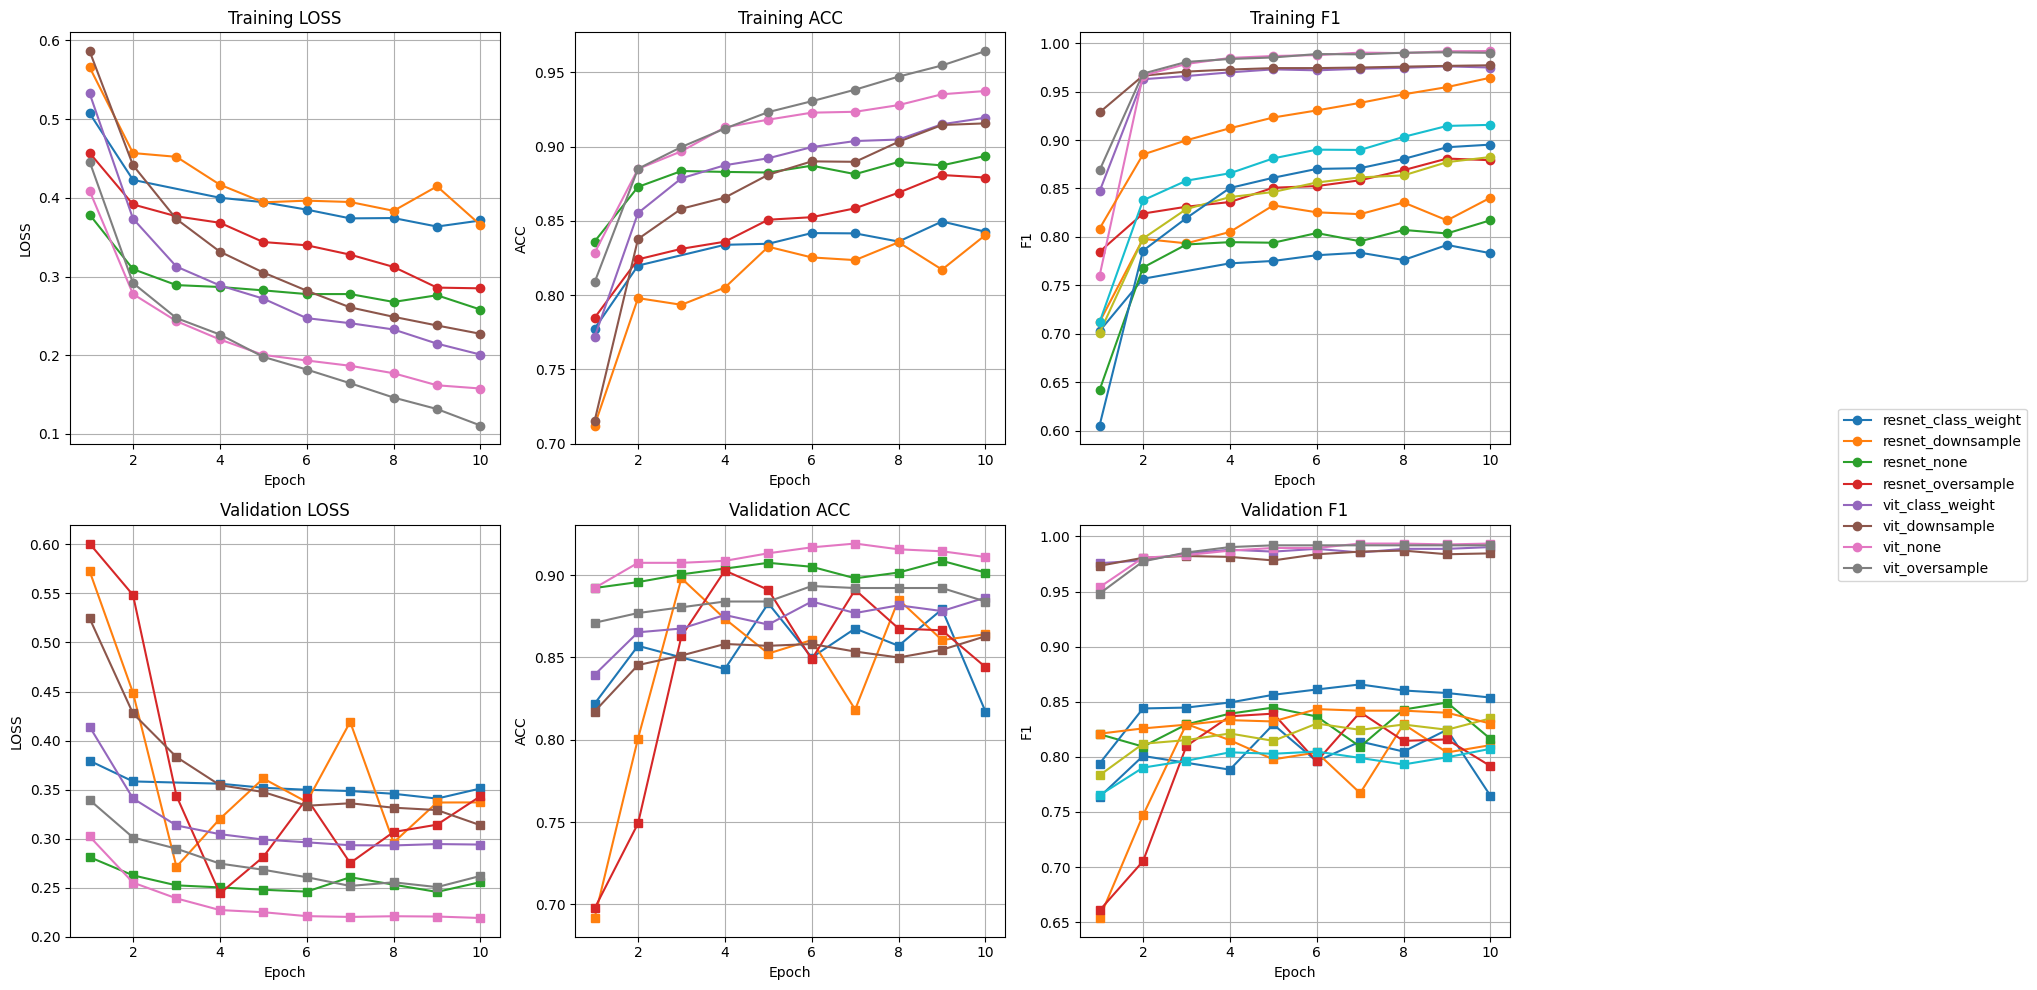

In [90]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = ['loss', 'acc', 'f1']

handles = []
labels = []

for i, metric in enumerate(metrics):
    ax_train = axes[0, i]
    ax_val = axes[1, i]

    for exp_name, data in experiments.items():
        epochs = data["epochs"]

        train_vals = data[f"train_{metric}"]
        val_vals = data[f"val_{metric}"]

        if len(train_vals) == 0 or len(val_vals) == 0:
            continue # if not present

        min_len = min(len(epochs), len(train_vals), len(val_vals))
        epochs_plot = epochs[:min_len]

        train_line, = ax_train.plot(
            epochs_plot,
            train_vals[:min_len],
            label=exp_name,
            marker="o"
        )

        ax_val.plot(
            epochs_plot,
            val_vals[:min_len],
            label=exp_name,
            marker="s"
        )

        if i == 0:
            handles.append(train_line)
            labels.append(exp_name)

    ax_train.set_title(f"Training {metric.upper()}")
    ax_train.set_xlabel("Epoch")
    ax_train.set_ylabel(metric.upper())
    ax_train.grid(True)

    ax_val.set_title(f"Validation {metric.upper()}")
    ax_val.set_xlabel("Epoch")
    ax_val.set_ylabel(metric.upper())
    ax_val.grid(True)

# Global legend
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=10
)

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

The data shows that Vision Transformers (ViT) generally outperform ResNet across all metrics. Models trained with oversampling tend to achieve the highest performance scores, while models using downsampling are consistently the most unstable and least effective. The ViT models show a much higher capacity to learn the training data (reaching near-perfect scores) but exhibit a notable gap between training and validation performance, indicating some degree of overfitting.

#### ResNet Performance

* **Best Variant: resnet_none (Standard)**
While `resnet_oversample` reaches slightly higher peak F1 scores at certain points, the standard `resnet_none` model is the most stable. it maintains a consistent upward trend in accuracy and F1 score with the least amount of "jitter" in the validation loss.
* **Worst Variant: resnet_downsample**
This is clearly the worst-performing ResNet model. Its validation metrics are extremely volatile, with sharp drops in accuracy and huge spikes in loss. This suggests that removing data to balance the classes deprived the model of the features it needed to generalize properly.

#### ViT (Vision Transformer) Performance

* **Best Variant: vit_oversample**
This model achieved the highest overall training and validation F1 scores. By replicating minority class samples, the Transformer was able to learn the nuances of the dataset more effectively than any other configuration. (Note: `vit_none` is a close runner-up as it achieved the lowest overall validation loss).
* **Worst Variant: vit_downsample**
Similar to the ResNet architecture, the downsampling strategy performed the poorest for ViT. It resulted in the lowest validation accuracy and F1 scores among the Transformer group, confirming that reducing the dataset size is detrimental to these high-capacity models.


#### Summary

The most reliable and high-performing model is **vit_oversample**. A more lightweight or stable alternative is **resnet_none** among the traditional architectures. **Downsampling** in both cases significantly degrades performance and stability.

### Test data

In [92]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


def build_test_records(test_csv_path):
    test_df = pd.read_csv(test_csv_path)

    unique_labels = sorted(
        test_df["label"].unique()
    )

    label_to_index = {
        label: idx
        for idx, label in enumerate(unique_labels)
    }

    index_to_label = {
        v: k
        for k, v in label_to_index.items()
    }

    records = []

    for _, row in test_df.iterrows():
        path = row["path"]

        # only prepend ../ if path is relative
        if not os.path.isabs(path):
            path = os.path.join("..", path)

        records.append({
            "path": path,
            "label": row["label"]
        })

    return records, label_to_index, index_to_label


# =====================================
# RQ1
# =====================================
rq1_test_records, rq1_label_to_index, rq1_index_to_label = build_test_records(
    "../outputs/splits/rq1_test_records.csv"
)

rq1_test_dataset = ImagePathDataset(
    rq1_test_records,
    rq1_label_to_index,
    transform=transform
)

rq1_test_loader = DataLoader(
    rq1_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("RQ1 labels:", rq1_label_to_index)
print("RQ1 size:", len(rq1_test_dataset))


# =====================================
# RQ3
# =====================================
rq3_test_records, rq3_label_to_index, rq3_index_to_label = build_test_records(
    "../outputs/splits/rq3_test_records.csv"
)

rq3_test_dataset = ImagePathDataset(
    rq3_test_records,
    rq3_label_to_index,
    transform=transform
)

rq3_test_loader = DataLoader(
    rq3_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

print("RQ3 labels:", rq3_label_to_index)
print("RQ3 size:", len(rq3_test_dataset))

RQ1 labels: {'accidental': 0, 'ordinary': 1}
RQ1 size: 853
RQ3 labels: {'ordinary': 0, 'paintings': 1}
RQ3 size: 1374


### Evaluation and Confusion Matrix

In [94]:
# ==========================================
# MODEL LOADING
# ==========================================
def load_model_for_evaluation(model_path, device):
    checkpoint = torch.load(
        model_path,
        map_location=device
    )

    print(f"\nLoading: {os.path.basename(model_path)}")

    # ----------------------------
    # Extract state dict
    # ----------------------------
    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    else:
        state_dict = checkpoint

    config = checkpoint.get("config", None)

    # =====================================================
    # CASE 1 → config exists (ideal)
    # =====================================================
    if config is not None:
        print("Using saved config:")
        print(config["model"])

        classifier_keys = [
            k for k in state_dict.keys()
            if (
                ("fc" in k or "heads.head" in k)
                and "weight" in k
            )
        ]

        final_key = sorted(classifier_keys)[-1]
        num_classes = state_dict[final_key].shape[0]

        model = build_model(
            config=config,
            num_classes=num_classes
        ).to(device)

    # =====================================================
    # CASE 2 → fallback for old checkpoints
    # =====================================================
    else:
        print("No config found → inferring architecture")

        # ----------------------------
        # Detect ViT vs ResNet
        # ----------------------------
        if any(k.startswith("heads.head") for k in state_dict.keys()):
            architecture = "vit_b_16"
            print("Detected ViT")

            vit_weight_keys = sorted([
                k for k in state_dict.keys()
                if k.startswith("heads.head") and "weight" in k
            ])

            print("ViT head keys:", vit_weight_keys)

            # -------------------------
            # Single linear head
            # -------------------------
            if len(vit_weight_keys) == 1:
                final_key = vit_weight_keys[0]

                num_classes = state_dict[
                    final_key
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True
                    }
                }

            # -------------------------
            # Sequential head
            # -------------------------
            elif len(vit_weight_keys) >= 2:
                first_key = vit_weight_keys[0]
                final_key = vit_weight_keys[-1]

                hidden_units = state_dict[
                    first_key
                ].shape[0]

                num_classes = state_dict[
                    final_key
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True,
                        "head_hidden": hidden_units,
                        "dropout": 0.5
                    }
                }

            else:
                raise ValueError(
                    f"Unknown ViT structure: {vit_weight_keys}"
                )

        else:
            architecture = "resnet50"
            print("Detected ResNet")

            # sequential head
            if "fc.1.weight" in state_dict:
                hidden_units = state_dict[
                    "fc.1.weight"
                ].shape[0]

                num_classes = state_dict[
                    "fc.4.weight"
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True,
                        "head_hidden": hidden_units,
                        "dropout": 0.5
                    }
                }

            elif "fc.0.weight" in state_dict:
                hidden_units = state_dict[
                    "fc.0.weight"
                ].shape[0]

                num_classes = state_dict[
                    "fc.3.weight"
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True,
                        "head_hidden": hidden_units,
                        "dropout": 0.5
                    }
                }

            else:
                num_classes = state_dict[
                    "fc.weight"
                ].shape[0]

                config = {
                    "model": {
                        "name": architecture,
                        "pretrained": True,
                        "freeze_backbone": True
                    }
                }

        print("Reconstructed config:")
        print(config)

        model = build_model(
            config=config,
            num_classes=num_classes
        ).to(device)

    # ----------------------------
    # Load weights
    # ----------------------------
    missing, unexpected = model.load_state_dict(
        state_dict,
        strict=False
    )

    if missing:
        print("Missing keys:", missing)

    if unexpected:
        print("Unexpected keys:", unexpected)

    model.eval()
    return model


# ==========================================
# MODEL EVALUATION
# ==========================================
def evaluate_model(model, test_loader, device):

    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for images, targets in test_loader:
            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)

            probs = F.softmax(
                outputs,
                dim=1
            )

            preds = outputs.argmax(dim=1)

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_targets.extend(
                targets.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    acc = accuracy_score(
        all_targets,
        all_preds
    )

    f1 = f1_score(
        all_targets,
        all_preds,
        average="weighted"
    )

    precision = precision_score(
        all_targets,
        all_preds,
        average="weighted"
    )

    recall = recall_score(
        all_targets,
        all_preds,
        average="weighted"
    )

    cm = confusion_matrix(
        all_targets,
        all_preds
    )

    # ROC only for binary
    if len(set(all_targets)) == 2:
        probs_positive = [
            p[1] for p in all_probs
        ]

        roc_auc = roc_auc_score(
            all_targets,
            probs_positive
        )
    else:
        roc_auc = None

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "roc_auc": roc_auc,
        "confusion_matrix": cm
    }


# ==========================================
# RUN EVALUATION
# ==========================================
test_results = {}

for exp_name in experiments.keys():

    model_path = os.path.join(
        outputs_dir,
        f"{exp_name}.pt"
    )

    if not os.path.exists(model_path):
        print(f"Missing model: {model_path}")
        continue

    print(f"\nEvaluating {exp_name}")

    # select proper test set
    if "rq3" in exp_name.lower():
        current_test_loader = rq3_test_loader

        labels = sorted(
            list(set(
                x["label"]
                for x in rq3_test_records
            ))
        )

    else:
        current_test_loader = rq1_test_loader

        labels = sorted(
            list(set(
                x["label"]
                for x in rq1_test_records
            ))
        )

    current_index_to_label = {
        idx: label
        for idx, label in enumerate(labels)
    }

    model = load_model_for_evaluation(
        model_path,
        device
    )

    metrics = evaluate_model(
        model,
        current_test_loader,
        device
    )

    metrics["index_to_label"] = current_index_to_label

    test_results[exp_name] = metrics


print("\nFinished evaluation")
print(test_results.keys())


# ==========================================
# FINAL TABLE
# ==========================================
final_metrics = {}

for exp_name, data in experiments.items():

    final_metrics[exp_name] = {
        "val_loss": data["val_loss"][-1] if len(data["val_loss"]) else None,
        "val_acc": data["val_acc"][-1] if len(data["val_acc"]) else None,
        "val_f1": data["val_f1"][-1] if len(data["val_f1"]) else None,

        "test_acc": test_results.get(exp_name, {}).get("accuracy"),
        "test_f1": test_results.get(exp_name, {}).get("f1"),
        "test_precision": test_results.get(exp_name, {}).get("precision"),
        "test_recall": test_results.get(exp_name, {}).get("recall"),
        "test_roc_auc": test_results.get(exp_name, {}).get("roc_auc"),
    }

comparison_df = pd.DataFrame.from_dict(
    final_metrics,
    orient="index"
)

print("\nFinal Comparison:")
display(comparison_df)


Evaluating resnet_class_weight

Loading: resnet_class_weight.pt
Using saved config:
{'name': 'resnet50', 'pretrained': True, 'freeze_backbone': True, 'head_hidden': 512, 'dropout': 0.3}

Evaluating resnet_downsample

Loading: resnet_downsample.pt
Using saved config:
{'name': 'resnet50', 'pretrained': True, 'freeze_backbone': True, 'head_hidden': 512, 'dropout': 0.3}

Evaluating resnet_none

Loading: resnet_none.pt
Using saved config:
{'name': 'resnet50', 'pretrained': True, 'freeze_backbone': True, 'head_hidden': 512, 'dropout': 0.3}

Evaluating resnet_oversample

Loading: resnet_oversample.pt
Using saved config:
{'name': 'resnet50', 'pretrained': True, 'freeze_backbone': True, 'head_hidden': 512, 'dropout': 0.3}

Evaluating rq3_resnet_keep_head

Loading: rq3_resnet_keep_head.pt
No config found → inferring architecture
Detected ResNet
Reconstructed config:
{'model': {'name': 'resnet50', 'pretrained': True, 'freeze_backbone': True, 'head_hidden': 512, 'dropout': 0.5}}

Evaluating rq3_r

,val_loss,val_acc,val_f1,test_acc,test_f1,test_precision,test_recall,test_roc_auc
resnet_class_weight,0.3444,0.8394,0.7867,0.889801,0.891237,0.893135,0.889801,0.909323
resnet_downsample,0.3369,0.8640,0.8106,0.876905,0.868368,0.869167,0.876905,0.895784
resnet_none,0.2556,0.9015,0.8163,0.888628,0.884772,0.883590,0.888628,0.915180
resnet_oversample,0.3432,0.8441,0.7916,0.890973,0.884154,0.885482,0.890973,0.910840
rq3_resnet_keep_head,NaN,NaN,0.9903,0.991994,0.991994,0.992020,0.991994,0.999534
rq3_resnet_reset_head,NaN,NaN,0.9846,0.988355,0.988355,0.988392,0.988355,0.999197
rq3_vit_keep_head,NaN,NaN,0.9935,0.993450,0.993450,0.993501,0.993450,0.999549
rq3_vit_reset_head,NaN,NaN,0.9919,0.986900,0.986898,0.987102,0.986900,0.998769
vit_class_weight,0.2939,0.8863,0.8349,0.873388,0.879835,0.894932,0.873388,0.946467
vit_downsample,0.3136,0.8628,0.8073,0.858148,0.867290,0.891669,0.858148,0.940136



Confusion Matrices:


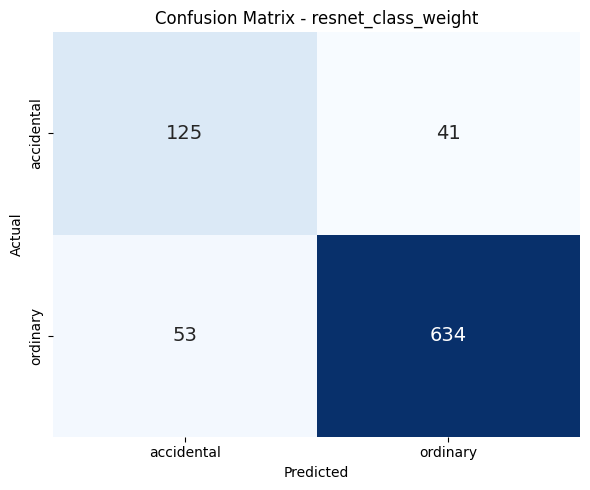

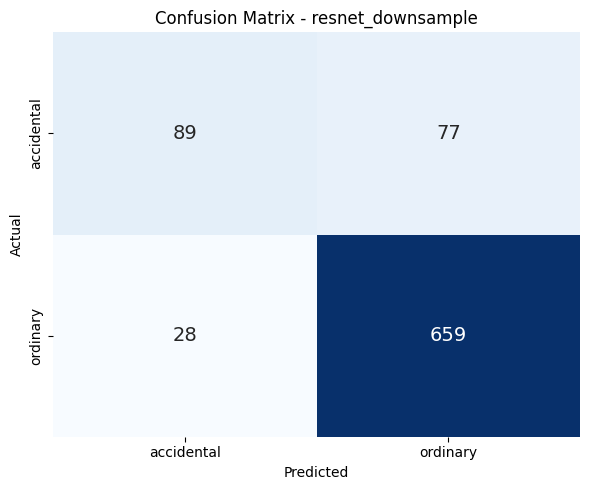

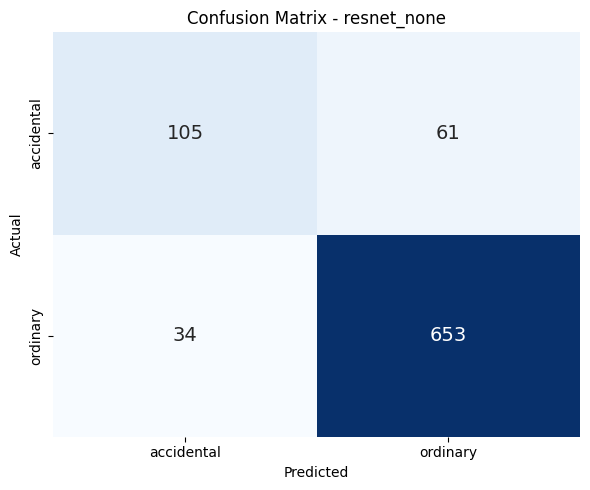

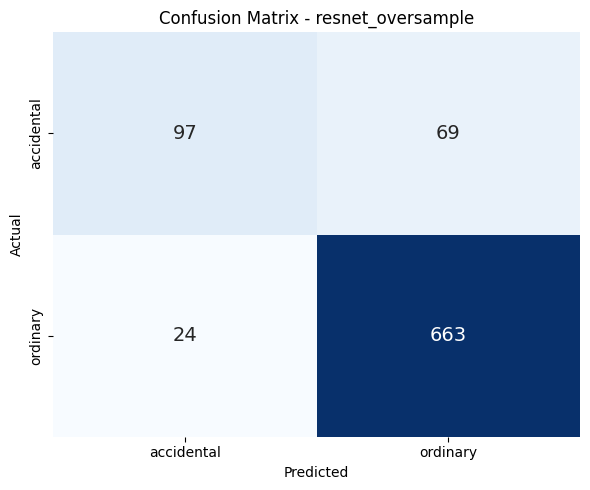

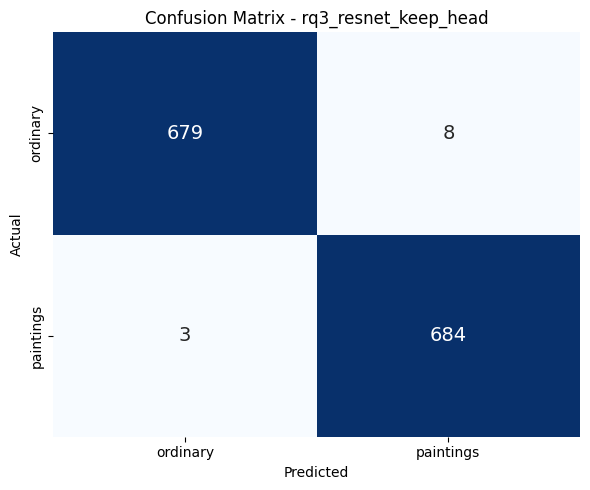

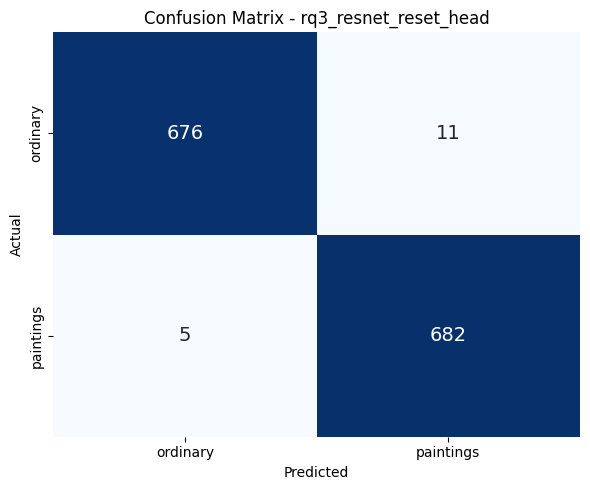

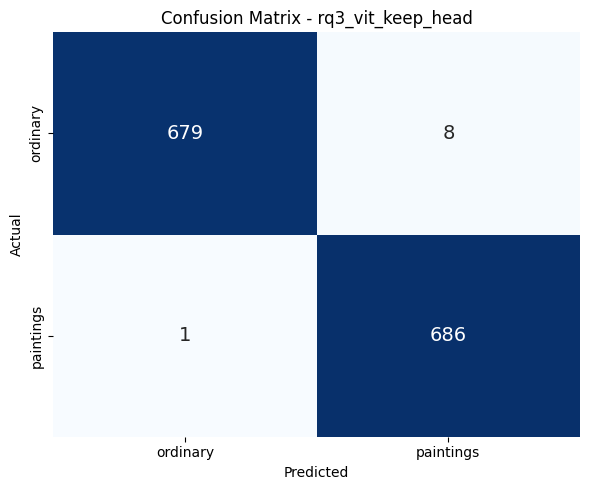

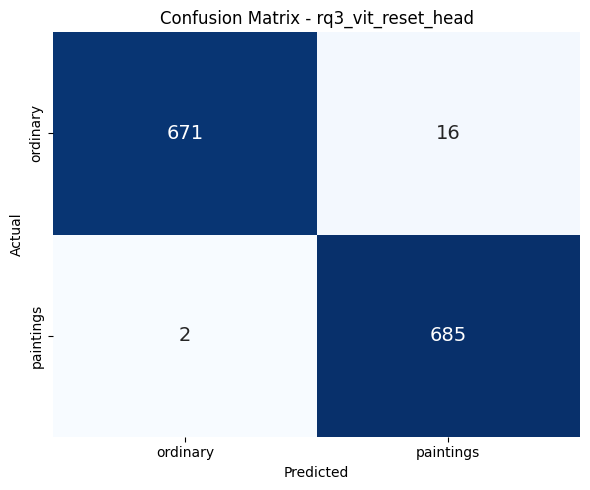

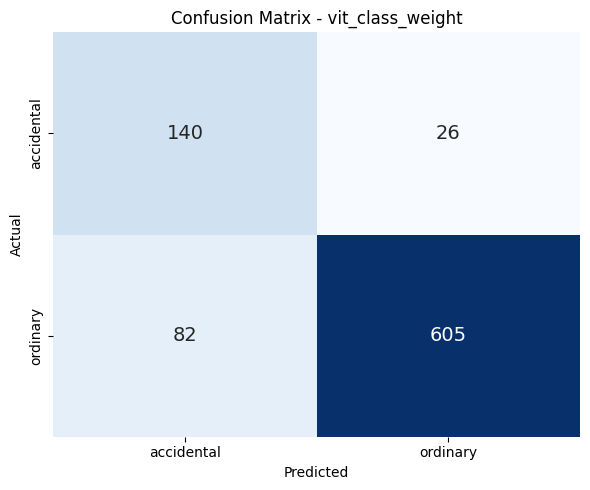

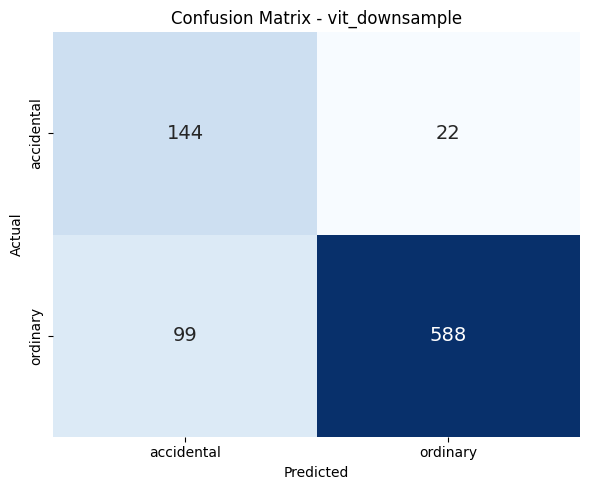

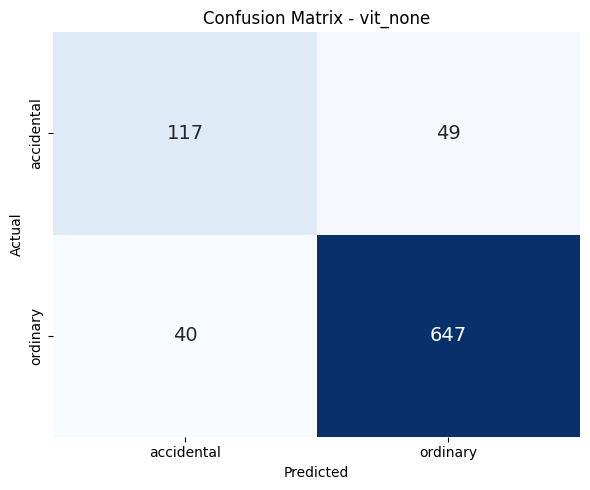

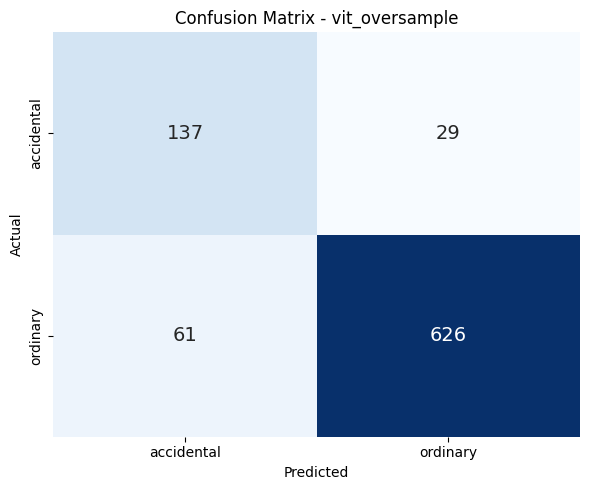

In [95]:
def plot_confusion_matrix(cm, exp_name, labels):
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={"size": 14},
        cbar=False
    )

    plt.title(f"Confusion Matrix - {exp_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


print("\nConfusion Matrices:")

for exp_name, metrics in test_results.items():

    labels = [
        metrics["index_to_label"][i]
        for i in sorted(metrics["index_to_label"].keys())
    ]

    plot_confusion_matrix(
        metrics["confusion_matrix"],
        exp_name,
        labels
    )

### Sample images analysis


Running predictions for resnet_class_weight

Loading: resnet_class_weight.pt
Using saved config:
{'name': 'resnet50', 'pretrained': True, 'freeze_backbone': True, 'head_hidden': 512, 'dropout': 0.3}

Running predictions for resnet_downsample

Loading: resnet_downsample.pt
Using saved config:
{'name': 'resnet50', 'pretrained': True, 'freeze_backbone': True, 'head_hidden': 512, 'dropout': 0.3}

Running predictions for resnet_none

Loading: resnet_none.pt
Using saved config:
{'name': 'resnet50', 'pretrained': True, 'freeze_backbone': True, 'head_hidden': 512, 'dropout': 0.3}

Running predictions for resnet_oversample

Loading: resnet_oversample.pt
Using saved config:
{'name': 'resnet50', 'pretrained': True, 'freeze_backbone': True, 'head_hidden': 512, 'dropout': 0.3}

Running predictions for rq3_resnet_keep_head

Loading: rq3_resnet_keep_head.pt
No config found → inferring architecture
Detected ResNet
Reconstructed config:
{'model': {'name': 'resnet50', 'pretrained': True, 'freeze_backbo

,index,path,true_label,resnet_class_weight,resnet_downsample,resnet_none,resnet_oversample,vit_class_weight,vit_downsample,vit_none,vit_oversample
0,0,..\data\raw\reddit_data\953ce3b2c8ace4d2.jpg,accidental,accidental,accidental,accidental,accidental,accidental,accidental,accidental,accidental
1,1,..\data\raw\coco_data\3277.jpg,ordinary,accidental,accidental,accidental,accidental,accidental,accidental,accidental,accidental
2,2,..\data\raw\coco_data\111.jpg,ordinary,ordinary,ordinary,ordinary,ordinary,ordinary,ordinary,ordinary,ordinary
3,3,..\data\raw\coco_data\1634.jpg,ordinary,ordinary,ordinary,ordinary,ordinary,ordinary,ordinary,ordinary,ordinary
4,4,..\data\raw\reddit_data\a9e75d3c294914b5.jpg,accidental,accidental,accidental,accidental,accidental,accidental,accidental,accidental,accidental



RQ3 sample predictions:


,index,path,true_label,rq3_resnet_keep_head,rq3_resnet_reset_head,rq3_vit_keep_head,rq3_vit_reset_head
0,0,C:\Users\lenaz\OneDrive\Documents\edu\uni\acci...,ordinary,ordinary,ordinary,ordinary,ordinary
1,1,C:\Users\lenaz\OneDrive\Documents\edu\uni\acci...,ordinary,ordinary,ordinary,ordinary,ordinary
2,2,C:\Users\lenaz\OneDrive\Documents\edu\uni\acci...,ordinary,ordinary,ordinary,ordinary,ordinary
3,3,C:\Users\lenaz\OneDrive\Documents\edu\uni\acci...,ordinary,ordinary,ordinary,ordinary,ordinary
4,4,C:\Users\lenaz\OneDrive\Documents\edu\uni\acci...,ordinary,ordinary,ordinary,ordinary,ordinary


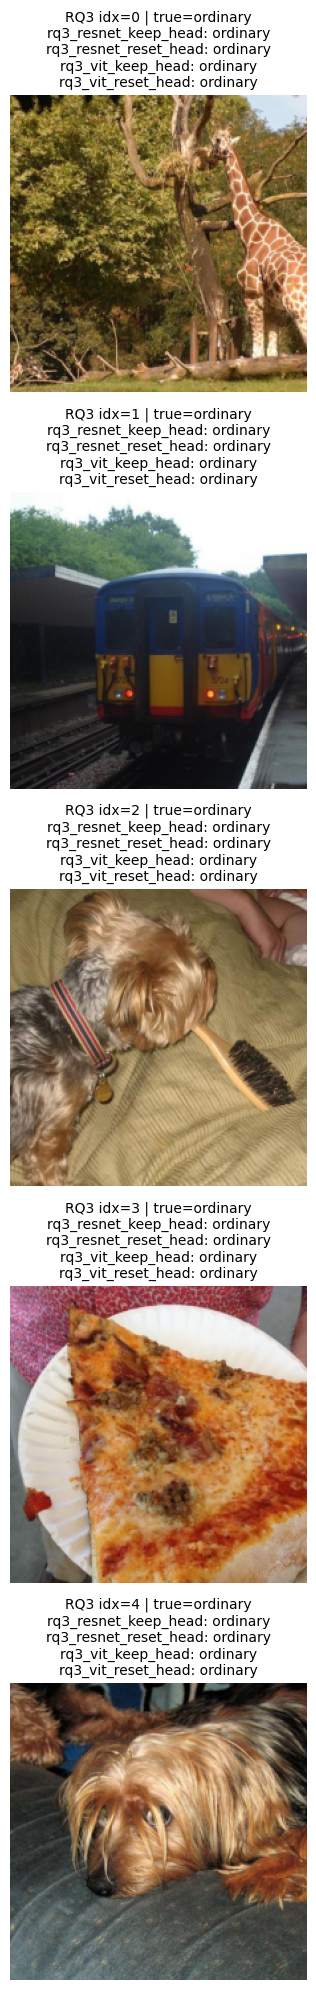

In [98]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import torch
from torchvision import transforms

sample_indices = [0, 1, 2, 3, 4]

model_preds = {}
sample_metadata = {}

for exp_name in experiments.keys():
    model_path = os.path.join(
        outputs_dir,
        f"{exp_name}.pt"
    )

    if not os.path.exists(model_path):
        print(f"Missing model: {exp_name}")
        continue

    print(f"\nRunning predictions for {exp_name}")

    # -----------------------------------
    # Select correct test set
    # -----------------------------------
    if "rq3" in exp_name.lower():
        current_loader = rq3_test_loader
        current_records = rq3_test_records
    else:
        current_loader = rq1_test_loader
        current_records = rq1_test_records

    dataset = current_loader.dataset

    sample_tensors = []

    for idx in sample_indices:
        img_tensor, _ = dataset[idx]
        sample_tensors.append(img_tensor)

    sample_images = torch.stack(
        sample_tensors
    ).to(device)

    # store metadata separately
    sample_metadata[exp_name] = {
        "records": current_records,
        "images": sample_images
    }

    try:
        model = load_model_for_evaluation(
            model_path,
            device
        )

        with torch.no_grad():
            outputs = model(sample_images)

            preds = outputs.argmax(
                dim=1
            ).cpu().tolist()

        model_preds[exp_name] = preds

    except Exception as e:
        print(f"Failed on {exp_name}: {e}")


# -----------------------------------
# Build separate tables for RQ1/RQ3
# -----------------------------------
rq1_rows = []
rq3_rows = []

for exp_name, preds in model_preds.items():

    records = sample_metadata[
        exp_name
    ]["records"]

    label_map = test_results[
        exp_name
    ]["index_to_label"]

    target_rows = (
        rq3_rows
        if "rq3" in exp_name.lower()
        else rq1_rows
    )

    for pos, idx in enumerate(sample_indices):
        existing = next(
            (
                r for r in target_rows
                if r["index"] == idx
            ),
            None
        )

        if existing is None:
            existing = {
                "index": idx,
                "path": records[idx]["path"],
                "true_label": records[idx]["label"]
            }
            target_rows.append(existing)

        existing[exp_name] = label_map.get(
            preds[pos],
            f"class_{preds[pos]}"
        )


rq1_sample_df = pd.DataFrame(rq1_rows)
rq3_sample_df = pd.DataFrame(rq3_rows)

print("\nRQ1 sample predictions:")
display(rq1_sample_df)

print("\nRQ3 sample predictions:")
display(rq3_sample_df)


# -----------------------------------
# Visualize separately
# -----------------------------------
inv_norm = transforms.Normalize(
    mean=[
        -m / s
        for m, s in zip(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ],
    std=[
        1 / s
        for s in [0.229, 0.224, 0.225]
    ]
)

for dataset_name in ["rq1", "rq3"]:
    relevant_models = [
        exp for exp in model_preds
        if dataset_name in exp.lower()
    ]

    if not relevant_models:
        continue

    records = (
        rq3_test_records
        if dataset_name == "rq3"
        else rq1_test_records
    )

    loader = (
        rq3_test_loader
        if dataset_name == "rq3"
        else rq1_test_loader
    )

    dataset = loader.dataset

    sample_tensors = []

    for idx in sample_indices:
        if idx >= len(dataset):
            print(
                f"Skipping idx {idx} for {dataset_name}: "
                f"dataset only has {len(dataset)} samples"
            )
            continue

        img_tensor, _ = dataset[idx]
        sample_tensors.append(img_tensor)

    sample_images = torch.stack(sample_tensors)

    fig, axes = plt.subplots(
        len(sample_indices),
        1,
        figsize=(10, 4 * len(sample_indices))
    )

    if len(sample_indices) == 1:
        axes = [axes]

    for pos, idx in enumerate(sample_indices):
        img = inv_norm(
            sample_images[pos]
        ).clamp(0, 1)

        img = img.permute(
            1, 2, 0
        ).numpy()

        ax = axes[pos]
        ax.imshow(img)
        ax.axis("off")

        pred_lines = "\n".join(
            f"{exp}: {test_results[exp]['index_to_label'][model_preds[exp][pos]]}"
            for exp in relevant_models
        )

        ax.set_title(
            f"{dataset_name.upper()} idx={idx} | true={records[idx]['label']}\n{pred_lines}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

RQ3 analysis